___
<img style="float: right; margin: 15px 15px 15px 15px;" src="https://img.freepik.com/free-photo/shop-clothing-clothes-shop-hanger-modern-shop-boutique_1150-8886.jpg" width="380px" height="200px" />


# <font color= #bbc28d> **Project 1 - Autoencoders** </font>
#### <font color= #2E9AFE> `Exploring the latent dimension in VAEs`</font>

<br><br><br>
___

<p style="text-align:right; font-size:12px;" > Image retrieved from: "https://img.freepik.com/free-photo/shop-clothing-clothes-shop-hanger-modern-shop-boutique_1150-8886.jpg</p>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
import pickle
import numpy as np
warnings.filterwarnings('ignore')
%matplotlib inline
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import load_model
import tensorflow as tf
from sklearn.cluster import KMeans
import numpy as np
from collections import Counter
from sklearn.decomposition import PCA
import plotly.express as px

# <font color=#bbc28d> **Introduction** </font>
This notebook explores the latent space learned by the Variational Autoencoder. We perform latent interpolation to visualize smooth transitions between samples and apply k-means clustering to group similar latent representations, helping us understand how the model organizes and represents the data.

## <font color= #66b0b0>• **Environment Preparation** </font>

Google Drive is mounted into the Google Colab environment. This allows the notebook to directly access files stored in cloud storage, such as datasets and preprocessed outputs.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# Load everything back
X = np.load("/content/drive/MyDrive/processed/X_images.npy")
y = np.load("/content/drive/MyDrive/processed/y_labels.npy")

# Label encoder
with open("/content/drive/MyDrive/processed/label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

print(X.shape)
print(y.shape)

(2906, 256, 256, 3)
(2906,)


Training data shapes: X=(2324, 256, 256, 3), y=(2324,)
Testing data shapes: X=(582, 256, 256, 3), y=(582,)


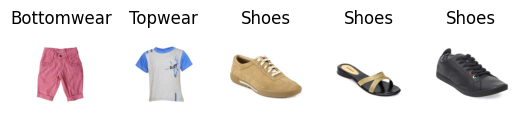

In [4]:
# Split both images and labels together
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  # stratify keeps label distribution

print('Training data shapes: X=%s, y=%s' % (x_train.shape, y_train.shape))
print('Testing data shapes: X=%s, y=%s' % (x_test.shape, y_test.shape))

for j in range(5):
    i = np.random.randint(0, x_train.shape[0])
    plt.subplot(1, 5, j+1)
    plt.imshow(x_train[i])
    plt.title(le.inverse_transform([y_train[i]])[0])  # <Take first element
    plt.axis('off')
plt.show()

## <font color= #66b0b0>• **Load Model** </font>
In our case, we will only use one of all the models we created for this project as we just want to show what can be done with the latent space of VAEs and why people shouldn't neglect it.
We will be using one of the best models we made **BASE MODEL WITH DIM=64**.

In [5]:
# Sampling function used in training for the reparametrization trick
def sampling(inputs):
    z_mean, z_log_var = inputs
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]

    # Epsilon is a Normal distribution N(0,1)
    epsilon = tf.keras.backend.random_normal(shape =(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# Load trained models
encoder = load_model("/content/drive/MyDrive/processed/Models/encoder_base_mse_64.keras", compile=False, custom_objects={"sampling": sampling})
decoder = load_model("/content/drive/MyDrive/processed/Models/decoder_base_mse_64.keras", compile=False)

# <font color=#bbc28d> **Latent Dimension Exploration** </font>
The main problem is that looking only at reconstructions doesn’t tell us what the VAE has really learned. The most valuable part of a VAE is its latent space, thanks to KL divergence regularization, this space is organized and smooth, meaning that nearby latent points correspond to semantically similar outputs. The problem is that if we only evaluate VAEs based on reconstruction quality, we miss this core benefit entirely.

## <font color= #66b0b0>• **K-Means** </font>
K-means clustering helps by grouping latent vectors that are close to each other; when we decode samples from the same cluster and see similar-looking images, it tells us that the VAE is organizing data by shared visual features.

In [ ]:
# Encode all images to latent space
z_latent = encoder.predict(x_test)[2] # Keep the z only

In [27]:
def kmeans(n_clusters=10, z_latent=z_latent, y_test=y_test, le=le):
    # KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_ids = kmeans.fit_predict(z_latent)

    # How many images per class p/ cluster
    for c in range(n_clusters):
        idx = np.where(cluster_ids == c)[0]
        true_labels = y_test[idx]
        counts = Counter(true_labels)

        formatted = ", ".join([f"{le.inverse_transform([cls])[0]}: {cnt}" for cls, cnt in counts.most_common()])
        print(f"Cluster {c}: {formatted}")

    # Plot it in 3D
    z_3d = PCA(n_components=3).fit_transform(z_latent)

    fig = px.scatter_3d(
        x=z_3d[:, 0],
        y=z_3d[:, 1],
        z=z_3d[:, 2],
        color=cluster_ids,
        title="3D PCA of VAE Latent Space",
        labels={"x": "PC1", "y": "PC2", "z": "PC3"},
        opacity=0.7
    )

    fig.show()

In our dataset we have 10 different classes, so we will first use that number of clusters to see if our model has learned the differences in between them:

In [29]:
kmeans(n_clusters=10)

Cluster 0: Topwear: 11, Apparel Set: 1, Dress: 1
Cluster 1: Topwear: 52
Cluster 2: Shoes: 63, Sandal: 7, Bottomwear: 1
Cluster 3: Shoes: 43
Cluster 4: Topwear: 30, Bottomwear: 16, Dress: 4, Apparel Set: 1
Cluster 5: Flip Flops: 13, Shoes: 6, Sandal: 2
Cluster 6: Shoes: 59, Flip Flops: 15, Sandal: 4
Cluster 7: Topwear: 16, Bottomwear: 14, Dress: 1
Cluster 8: Topwear: 87, Shoes: 52, Bottomwear: 17, Dress: 9, Innerwear: 2, Socks: 2, Flip Flops: 2, Sandal: 1
Cluster 9: Shoes: 39, Sandal: 11


As we can see, visually there is almost no separation in between clusters, and the classes are all mixed. We can infer that our VAE has problems identifying clearly the characteristics of each class.

However, we can try a different approach, we have 10 original classes, but we can also treat them as subclasses, and separate them into clothes and shoes, having a total of 2 classes which in theory share some similarities as they are not so far from each other so let´s try that.

In [28]:
kmeans(n_clusters=2)

Cluster 0: Topwear: 195, Bottomwear: 42, Dress: 15, Shoes: 5, Innerwear: 2, Apparel Set: 2, Socks: 2, Sandal: 1, Flip Flops: 1
Cluster 1: Shoes: 257, Flip Flops: 29, Sandal: 24, Bottomwear: 6, Topwear: 1


As we can see, K-means does a better job at generalizing and separating the clusters, so our model can clearly differenciate between clothing articles and shoes.

## <font color= #66b0b0>• **Interpolation** </font>
Interpolation helps by taking two latent points and smoothly moving from one to the other; when the decoded images change gradually and naturally, it shows that the model learned a continuous and meaningful representation instead of jumping randomly between examples.

In [35]:
# Pick two images
x1 = x_test[0:1]
x2 = x_test[2:3]

# List of alphas values
alphas = np.linspace(0, 1, num=10)

In [36]:
def interpolation(x1=x1, x2=x2, alphas=alphas, encoder=encoder, decoder=decoder):
  # Encode to latent vectors
  z1 = encoder.predict(x1)[2]
  z2 = encoder.predict(x2)[2]

  # Interpolation
  z_interp_list = [(1-alpha)*z1 + alpha*z2 for alpha in alphas]

  # Decode interpolations
  imgs_interp = [decoder.predict(z) for z in z_interp_list]

  # Plot original + interpolation
  plt.figure(figsize=(20, 4))

  # Original image 1
  plt.subplot(1, len(imgs_interp)+2, 1)
  plt.imshow(x1[0])
  plt.title("Original 1")
  plt.axis("off")

  # Original image 2
  plt.subplot(1, len(imgs_interp)+2, len(imgs_interp)+2)
  plt.imshow(x2[0])
  plt.title("Original 2")
  plt.axis("off")

  # Interpolated images
  for i, img in enumerate(imgs_interp):
      plt.subplot(1, len(imgs_interp)+2, i+2)
      plt.imshow(img[0])
      plt.title(f"{alphas[i]:.2f}")
      plt.axis("off")

  plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


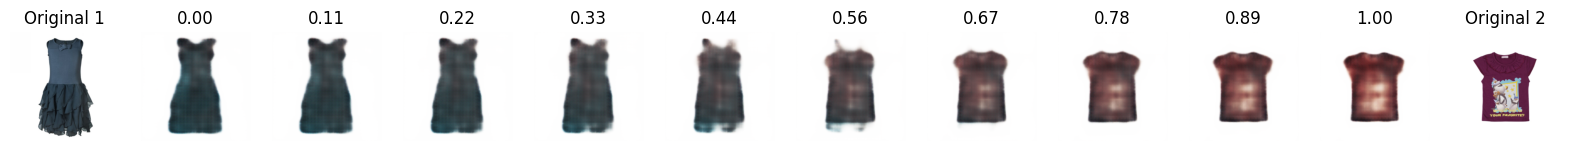

In [37]:
interpolation(x1=x1, x2=x2, alphas=alphas, encoder=encoder, decoder=decoder)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


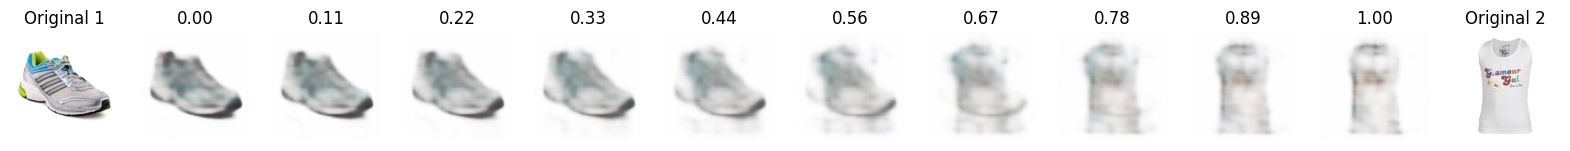

In [40]:
# Pick two images
x1 = x_test[4:5]
x2 = x_test[10:11]

# List of alphas values
alphas = np.linspace(0, 1, num=10)

interpolation(x1=x1, x2=x2, alphas=alphas, encoder=encoder, decoder=decoder)

As we can see, our images transition smoothly between each other, resulting in images which are not the clearest, but can be used as a starting point if a brand wants to come out with a new collection.

Maybe we can also pair this images with data processing techniques to make them clearer and generate "better" images.